17000
stft shape=(8193, 216)


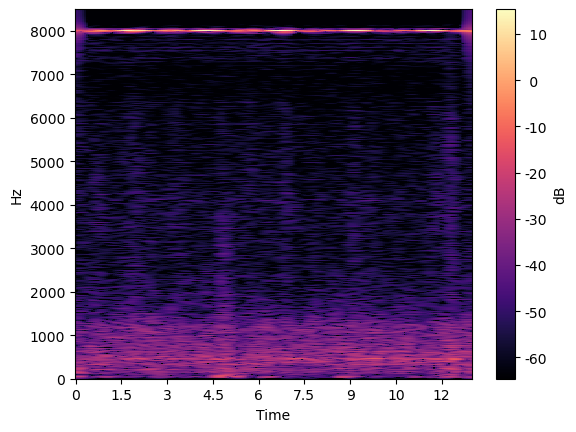

[7711 7711 7703 7703 7703 7703 7703 7703 7700 7700 7700 7700 7700 7700
 7700 7701 7707 7707 7707 7707 7707 7707 7707 7713 7713 7714 7714 7719
 7719 7720 7720 7720 7720 7720 7720 7720 7717 7717 7708 7708 7708 7711
 7711 7711 7712 7704 7704 7701 7701 7700 7700 7700 7700 7700 7701 7701
 7701 7702 7707 7707 7707 7714 7714 7714 7714 7714 7718 7718 7719 7719
 7719 7720 7720 7720 7720 7720 7719 7716 7714 7714 7714 7713 7713 7712
 7706 7706 7704 7704 7701 7701 7701 7701 7701 7701 7701 7701 7705 7705
 7705 7705 7709 7709 7709 7710 7710 7712 7712 7718 7718 7719 7719 7719
 7719 7719 7719 7719 7719 7718 7716 7716 7707 7707 7707 7707 7707 7707
 7707 7707 7702 7702 7701 7701 7701 7701 7701 7702 7702 7702 7703 7704
 7705 7713 7713 7713 7707 7707 7716 7716 7717 7718 7718 7719 7719 7719
 7719 7719 7719 7718 7709 7709 7709 7710 7710 7710 7710 7710 7710 7711
 7705 7702 7702 7702 7702 7702 7702 7702 7702 7702 7703 7705 7706 7706
 7707 7707 7707 7707 7707 7716 7717 7718 7718 7718 7719 7719 7719 7719
 7719 

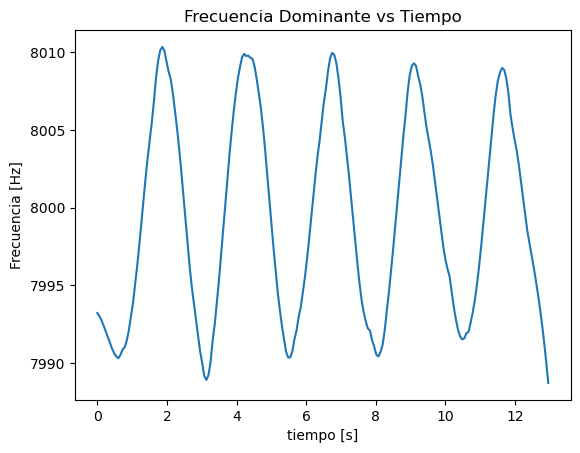

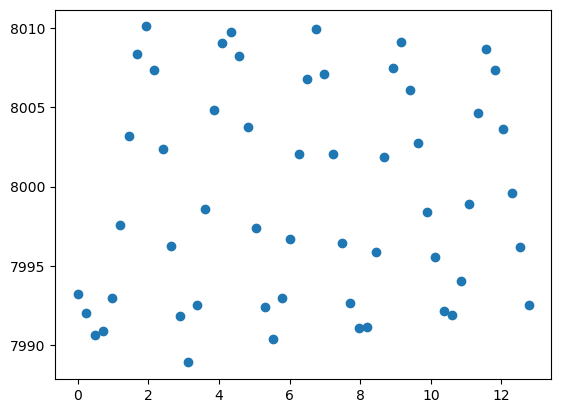

In [1]:
#PÉNDULO SIMPLE

#código sacado en su mayoría desde https://github.com/librosa/librosa/blob/main/docs/tutorials/02-display/02-spectrogram.py,
#borré la mayor parte de comentarios en inglés. las partes hechas por mí tienen nombres y comentarios poco serios, pero respetenlo.
# %%
# .. _tutorial-display-spectrogram:
#
# Spectrograms
# ------------
# The :ref:`earlier sections <tutorial-intro-frequency>` of this tutorial demonstrate basic
# usage of the short-time Fourier transform (STFT), which can be useful for visualizing how
# the frequency content of a signal changes over time.
# This kind of visualization is known as a **spectrogram**, and you may have encountered
# this idea before.
# While spectrograms can be interpreted as *images* and displayed using `matplotlib`'s
# general-purpose image display functions (e.g. `matplotlib.pyplot.imshow`), there are several
# subtleties that can arise and it takes a bit of effort to get it right.
#
# As an example, let's create an STFT and display it using `imshow` directly.
# We'll first set up our imports and load an example file.

# sphinx_gallery_thumbnail_number = 6
from scipy.signal import medfilt, savgol_filter
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import HTML
ruta_acceso = r"C:\Users\A\OneDrive\Escritorio\tópicos\audios\prueba_pendulo_a31.wav"
srr = 17000
hop_lengthh = 1024
y, sr = librosa.load(ruta_acceso, sr = srr, offset=1.19, duration=13.0) #sr = None para aumentar las muestras
print(sr)
#Si la frecuencia de muestreo es 44 100 muestras por cada segundo, puedo despejar el tiempo para el cual el código calculará las frecuencias
#y usarlo para determinar el armónico más fuerte del espectro, haciendo (indice * hop_length)/tasa_muestreo
# %%
# Now we can compute the STFT, create a figure, and call `imshow`.
# Note that when we call `imshow`, we have to convert the `stft` array from complex to real, or
# else it will fail due to a type mismatch.
resolucion = 16384
stft = librosa.stft(y, hop_length = hop_lengthh, n_fft = resolucion)
print(f"stft shape={stft.shape}")
#fig, ax = plt.subplots()
#ax.imshow(np.abs(stft))
#esta parte la hice yo, quizas se puede hacer más rápido con numpy pero usé lo que sabía perdoneme profe
t= np.zeros(stft.shape[1])
for i in range(0, stft.shape[1]):
    t[i] = (i*hop_lengthh)/srr    

#fig, ax = plt.subplots()
#librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB")
fig, ax = plt.subplots()
img = librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB", sr=srr, hop_length = hop_lengthh)
librosa.display.colorbar_db(img)
plt.savefig("Espectrograma_Péndulo_A31.pdf")
plt.show()
frecuencias = librosa.fft_frequencies(sr=srr, n_fft=resolucion)
frecuencias_absolutas = np.abs(stft) #por si acaso? me dijeron que lo haga
#ahora voy a filtrar un rango de frecuencia
frecuencias_filtradas = []
indices_frecuencias_filtradas = []
amplitudes_filtradas = []

for i in range(0, len(frecuencias)):
    if frecuencias[i]>=7800 and frecuencias[i]<=8200:
        frecuencias_filtradas.append(frecuencias[i])
        amplitudes_filtradas.append(frecuencias_absolutas[i, :])
        
#paso las listas a arreglos numpy para trabajarlos más fácil y que me compile el codigo
frecuencias_filtradas = np.array(frecuencias_filtradas)
amplitudes_filtradas = np.array(amplitudes_filtradas)
indices_frecuencias_filtradas = np.argmax(amplitudes_filtradas, axis=0)
f_dominante = frecuencias_filtradas[indices_frecuencias_filtradas]

f_dominante_promedio = medfilt(f_dominante, kernel_size=7) #esto lo hice con IA, se supone que filtra el ruido
indices_f_max = np.argmax(frecuencias_absolutas, axis=0) 
print(indices_f_max) #no muestra todos los indices pero elijo confiar? el np.argmax sin el axis=0 me devuelve un único valor (imagino que de todo el audio)
#esta parte si funciona pero hay código que no usamos realmente, son vestigios de codigos anteriores
no_se_si_funciona = frecuencias[indices_f_max]
print(no_se_si_funciona)

#un ajuste lineal para que los gráficos no se vean no continuos
f_continua = savgol_filter(f_dominante_promedio, window_length=21, polyorder=3) #esto lo hice con IA


largo_f_continua = len(f_continua)
print(largo_f_continua)

#extraigo una muestra para no graficar como 200 puntos de velocidad, la muestra ES representativa porque pasó por promedios y ajustes
f_continua_muestra = f_continua[0:largo_f_continua:4]
t_f_continua_muestra = t[0:largo_f_continua:4]


plt.plot(t, f_continua)
plt.xlabel("tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.title("Frecuencia Dominante vs Tiempo")
plt.savefig("Frecuencia_Dominante_PénduloA31.pdf")
plt.show()
plt.scatter(t_f_continua_muestra, f_continua_muestra)
plt.show()



#plt.plot(t_f_dom, f_dominante)
#plt.show()
#Ahora nos falta separar los gráficos y hacer una máscara AYUDAAAAAAA




#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB")
#librosa.display.colorbar_db(img)


#fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[4, 1])
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB", ax=ax[0])
#librosa.display.colorbar_db(img)


#ax[0].legend(loc="upper right")
#ax[0].label_outer("ola")
#librosa.display.waveshow(y=y, sr=sr, ax=ax[1])



# Use the native sampling rate of the example by setting sr=None
#y, sr = librosa.loadx(ruta_acceso, sr=None)

# Use larger frames (4096 samples) to account for the higher sampling rate
# Use a smaller hop length to get a higher time resolution in the stft
#stft = librosa.stft(y, n_fft=8192, hop_length=256)
#print(f"stft shape={stft.shape}")

# %%
# Now we can supply our analysis parameters to `specshow` so that axes are constructed
# properly.
# While we're at it, we can also change the threshold for decibel scaling by setting `top_db`
# (which defaults to 80, but let's set it to 60 to suppress low-amplitude noise).
# Finally, we can choose a different colormap for sequential data by setting `cmap_seq=`.
# Here we'll use a black-on-white colormap, suitable for print media.

#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB",
                              # sr=sr, hop_length=256, top_db=60,
                               #cmap_seq="gray_r")
#librosa.display.colorbar_db(img)

# %%
# Summary and tips
# ----------------
# We've really only scratched the surface when it comes to the functionality provided by
# `specshow`, and the subsequent sections in this tutorial will dig into the details.
#
# A few things that can be helpful to keep in mind:
#   - The most important parameters are `x_axis` and `y_axis`.  Most of the remaining
#     parameters are there to support unit conversion for different axis scalings.
#   - There is nothing special about the orientation here: any axis can be a time axis or a
#     frequency axis.  This makes it easy to draw sideways spectrograms, time-by-time plots,
#     frequency-by-frequency plots, etc.  The section on :ref:`non-spectral <tutorial-display-nonspectral>`
#     data visualization provides some examples of this.
#   - The underlying display object is generated by `matplotlib.pyplot.pcolormesh`.  Any
#     parameters acceptable to `pcolormesh` can be passed into `specshow` as well.





In [2]:
#ahora procedo a medir la desviación estándar al rededor de los 8000Hz de el mismo sistema pero en reposo
import numpy as np
import librosa
from scipy.signal import medfilt, savgol_filter

# 1. Cargar el audio en reposo (cambia la ruta a tu archivo de calibración)
ruta_reposo = r"C:\Users\A\OneDrive\Escritorio\tópicos\audios\prueba_reposo_pendulo.wav"
srr = 17000
hop_lengthh = 1024
resolucion = 16384

y_reposo, sr_reposo = librosa.load(ruta_reposo, sr=srr, offset=5.0, duration=10.0)

stft_reposo = librosa.stft(y_reposo, hop_length=hop_lengthh, n_fft=resolucion)
frecuencias_absolutas_reposo = np.abs(stft_reposo)
frecuencias = librosa.fft_frequencies(sr=srr, n_fft=resolucion)

frecuencias_filtradas_rep = []
amplitudes_filtradas_rep = []

for i in range(0, len(frecuencias)):
    if frecuencias[i] >= 7800 and frecuencias[i] <= 8200:
        frecuencias_filtradas_rep.append(frecuencias[i])
        amplitudes_filtradas_rep.append(frecuencias_absolutas_reposo[i, :])

frecuencias_filtradas_rep = np.array(frecuencias_filtradas_rep)
amplitudes_filtradas_rep = np.array(amplitudes_filtradas_rep)

indices_frecuencias_filtradas_rep = np.argmax(amplitudes_filtradas_rep, axis=0)
f_dominante_reposo = frecuencias_filtradas_rep[indices_frecuencias_filtradas_rep]


f_dominante_promedio_rep = medfilt(f_dominante_reposo, kernel_size=7)
f_continua_reposo = savgol_filter(f_dominante_promedio_rep, window_length=21, polyorder=3)

# calculo la desviación estándar al rededor del valor 8000, que uso para despejar la velocidad
error_f_rep = np.sqrt(np.mean((f_continua_reposo - 8000)**2))
print(error_f_rep)

0.12207031260879081


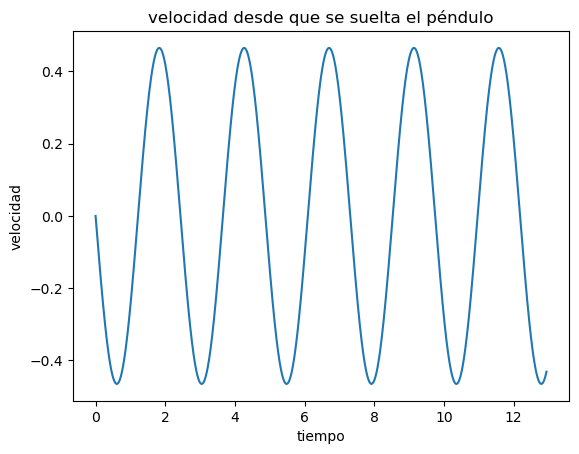

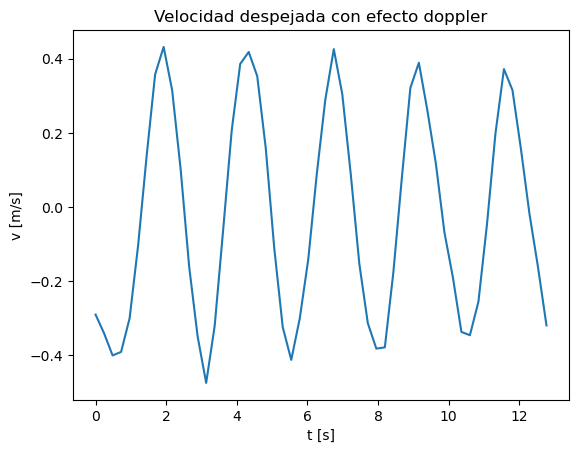

In [3]:
#grafica numérica de la velocidad usando runge kutta para solucionar pendulo simple
#catetos opuestos iniciales: 1=0.06, 2=0.11, 3=0.19, hice una prueba única con cateto opuesto = 0.4 todo en metros
import numpy as np
import matplotlib.pyplot as plt
L = 1.472
L_microfono = 1.392
g = 9.81
theta_0 = np.arcsin(0.19/L)
v_0 = 0
duracion_audio = t[-1]
h=0.01
Ntiempos = int(duracion_audio/h)
trk4 = np.arange(Ntiempos)*h
x=np.zeros([Ntiempos, 2])
x[0, 0] = theta_0
x[0,1] = v_0
def f(x, trk4, g=9.81, L=1.472):
    theta, velocidad = x
    return np.array([velocidad, -(g/L)*np.sin(theta)])
for i in range(Ntiempos-1):
     K1 = f(x[i], trk4[i])
     K2 = f(x[i]+K1*h/2, trk4[i]+h/2)
     K3 = f(x[i]+K2*h/2, trk4[i]+h/2)
     K4 = f(x[i]+K3*h , trk4[i]+h)
     x[i+1] = x[i] + (K1 + 2*K2 + 2*K3 + K4)*(h/6)
theta = x[:,0]
velocidad = x[:,1]

plt.plot(trk4, velocidad*L_microfono)
plt.title("velocidad desde que se suelta el péndulo")
plt.xlabel("tiempo")
plt.ylabel("velocidad")
plt.show()




#Ahora programo las formulas del efecto doppler
T = 273.15 +18.6
V_sonido = np.sqrt((1.4*8.314*T)/0.029)
f_emitida = 8000
velocidades_receptor = np.zeros(len(f_continua))
for i in range(0, len(t_f_continua_muestra)):
 v_r = V_sonido*((f_continua_muestra/f_emitida)-1) #porque es un arreglo de numpy (debería funcionar)
plt.plot(t_f_continua_muestra, v_r)
plt.xlabel("t [s]")
plt.ylabel("v [m/s]")
plt.title("Velocidad despejada con efecto doppler")
plt.show()



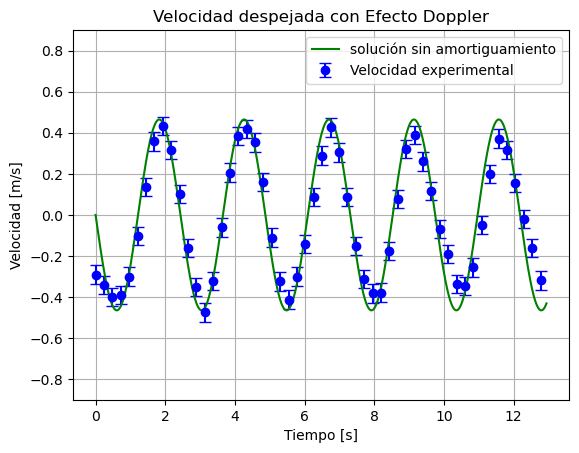

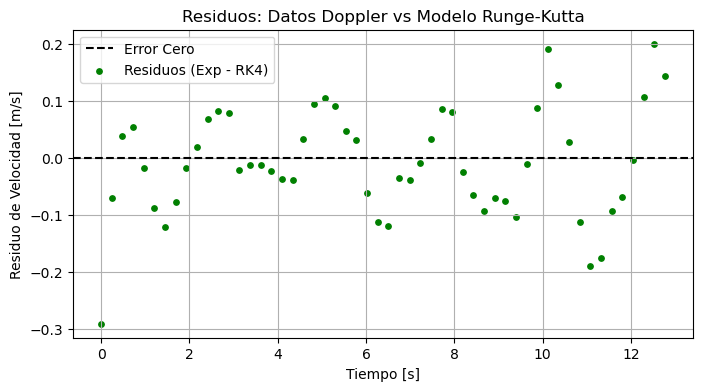

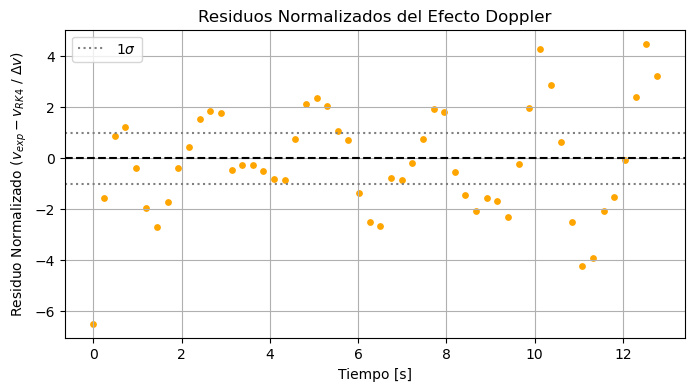

In [4]:
#análisis de error propagado en la velocidad
import numpy as np
error_termometro = 1
error_Hz_recibido = srr/resolucion
dv_vs = (f_continua_muestra/f_emitida)-1
dv_fr = V_sonido*(1/f_emitida)
dv_fe = V_sonido*(-(f_continua_muestra/f_emitida**2))
error_v_sonido = 0.5*np.abs((1/(np.sqrt(T)))*np.sqrt(1.4*8.314/0.029))*error_termometro
error_velocidad = np.sqrt((dv_vs*error_v_sonido)**2+(dv_fr*error_Hz_recibido)**2+(dv_fe*error_f_rep)**2) 

plt.errorbar(t_f_continua_muestra, v_r, yerr=error_velocidad, fmt='o', capsize=4, color='blue', label="Velocidad experimental")
plt.plot(trk4, velocidad*L_microfono, color="green", label="solución sin amortiguamiento")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.title("Velocidad despejada con Efecto Doppler")
plt.grid(True)
plt.legend()
plt.ylim((-0.9, 0.9))
plt.savefig("Comparacion_Velocidad_PenduloA31.pdf")
plt.show()

#créditos a la IA que lo hizo rápido
v_teorica_interpolada = np.interp(t_f_continua_muestra, trk4, velocidad * L_microfono)

# 2. Calcular los residuos (Datos Experimentales Doppler - Modelo Teórico RK4)
residuos_rk4 = v_r - v_teorica_interpolada

# 3. Graficar los residuos
plt.figure(figsize=(8, 4))

# Línea base de error cero
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label="Error Cero")

# Puntos de los residuos
plt.scatter(t_f_continua_muestra, residuos_rk4, color='green', s=15, label="Residuos (Exp - RK4)")

plt.xlabel("Tiempo [s]")
plt.ylabel("Residuo de Velocidad [m/s]")
plt.title("Residuos: Datos Doppler vs Modelo Runge-Kutta")
plt.legend()
plt.grid(True)
plt.show()

residuos_normalizados = residuos_rk4 / error_velocidad

# Graficar
plt.figure(figsize=(8, 4))
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='gray', linestyle=':', label=r'$1\sigma$')
plt.axhline(-1, color='gray', linestyle=':')

plt.scatter(t_f_continua_muestra, residuos_normalizados, color='orange', s=15)
plt.xlabel("Tiempo [s]")
plt.ylabel(r"Residuo Normalizado ($v_{exp} - v_{RK4}$ / $\Delta v$)")
plt.title("Residuos Normalizados del Efecto Doppler")
plt.legend()
plt.grid(True)
plt.savefig("ResiduosN_PénduloA31.pdf")
plt.show()

17000
stft shape=(8193, 208)


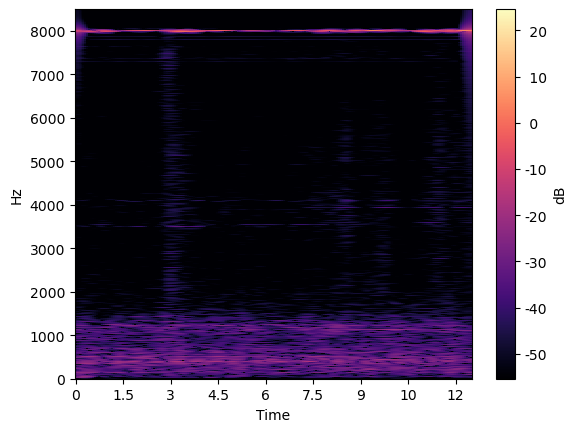

[7709 7709 7709 7709 7709 7709 7709 7708 7708 7707 7707 7707 7707 7707
 7707 7707 7707 7707 7708 7708 7710 7710 7710 7710 7710 7710 7710 7712
 7713 7713 7713 7713 7713 7713 7713 7713 7713 7713 7712 7712 7711 7711
 7710 7710 7710 7710 7709 7709 7708 7708 7708 7707 7707 7707 7707 7707
 7707 7707 7708 7708 7708 7710 7710 7710 7710 7710 7710 7710 7712 7713
 7713 7713 7713 7713 7713 7713 7713 7713 7710 7711 7711 7711 7710 7710
 7710 7710 7710 7710 7709 7708 7707 7707 7707 7707 7707 7707 7707 7708
 7708 7708 7708 7708 7711 7710 7710 7710 7710 7710 7712 7712 7713 7713
 7713 7713 7713 7713 7713 7713 7713 7712 7711 7711 7711 7710 7710 7710
 7710 7710 7710 7710 7708 7707 7707 7707 7707 7707 7707 7707 7708 7708
 7708 7710 7710 7710 7710 7710 7710 7710 7710 7710 7713 7713 7713 7713
 7713 7713 7713 7713 7713 7710 7710 7710 7710 7710 7710 7710 7710 7710
 7710 7710 7708 7708 7708 7707 7707 7707 7707 7707 7708 7708 7710 7710
 7710 7710 7710 7710 7710 7710 7710 7712 7712 7713 7713 7713 7713 7713
 7713 

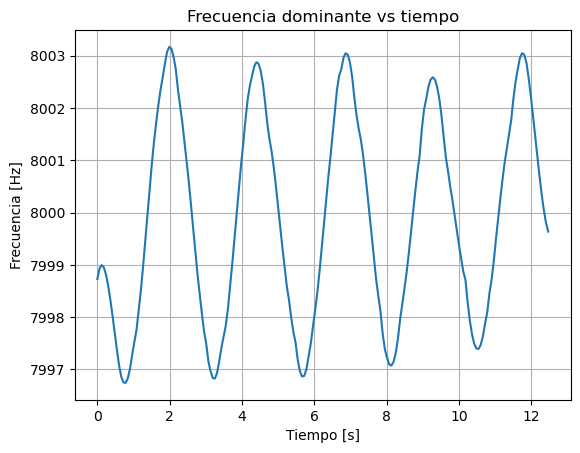

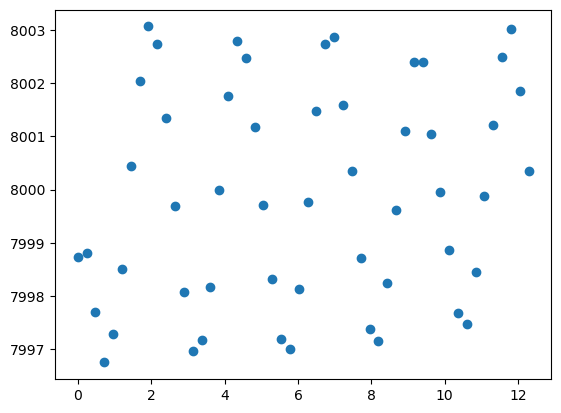

In [5]:
#PÉNDULO SIMPLE

#código sacado en su mayoría desde https://github.com/librosa/librosa/blob/main/docs/tutorials/02-display/02-spectrogram.py,
#borré la mayor parte de comentarios en inglés. las partes hechas por mí tienen nombres y comentarios poco serios, pero respetenlo.
# %%
# .. _tutorial-display-spectrogram:
#
# Spectrograms
# ------------
# The :ref:`earlier sections <tutorial-intro-frequency>` of this tutorial demonstrate basic
# usage of the short-time Fourier transform (STFT), which can be useful for visualizing how
# the frequency content of a signal changes over time.
# This kind of visualization is known as a **spectrogram**, and you may have encountered
# this idea before.
# While spectrograms can be interpreted as *images* and displayed using `matplotlib`'s
# general-purpose image display functions (e.g. `matplotlib.pyplot.imshow`), there are several
# subtleties that can arise and it takes a bit of effort to get it right.
#
# As an example, let's create an STFT and display it using `imshow` directly.
# We'll first set up our imports and load an example file.

# sphinx_gallery_thumbnail_number = 6
from scipy.signal import medfilt, savgol_filter
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import HTML
ruta_acceso = r"C:\Users\A\OneDrive\Escritorio\tópicos\audios\prueba_pendulo_a11.wav"
srr = 17000
hop_lengthh = 1024
y, sr = librosa.load(ruta_acceso, sr = srr, offset = 4.0, duration = 12.5) #sr = None para aumentar las muestras
print(sr)
#Si la frecuencia de muestreo es 44 100 muestras por cada segundo, puedo despejar el tiempo para el cual el código calculará las frecuencias
#y usarlo para determinar el armónico más fuerte del espectro, haciendo (indice * hop_length)/tasa_muestreo
# %%
# Now we can compute the STFT, create a figure, and call `imshow`.
# Note that when we call `imshow`, we have to convert the `stft` array from complex to real, or
# else it will fail due to a type mismatch.
resolucion = 16384
stft = librosa.stft(y, hop_length = hop_lengthh, n_fft = resolucion)
print(f"stft shape={stft.shape}")
#fig, ax = plt.subplots()
#ax.imshow(np.abs(stft))
#esta parte la hice yo, quizas se puede hacer más rápido con numpy pero usé lo que sabía perdoneme profe
t= np.zeros(stft.shape[1])
for i in range(0, stft.shape[1]):
    t[i] = (i*hop_lengthh)/srr    

#fig, ax = plt.subplots()
#librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB")
fig, ax = plt.subplots()
img = librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB", sr=srr, hop_length = hop_lengthh)
librosa.display.colorbar_db(img)
plt.savefig("Espectrograma_PénduloA1.pdf")
plt.show()
frecuencias = librosa.fft_frequencies(sr=srr, n_fft=resolucion)
frecuencias_absolutas = np.abs(stft) #por si acaso? me dijeron que lo haga
#ahora voy a filtrar un rango de frecuencia
frecuencias_filtradas = []
indices_frecuencias_filtradas = []
amplitudes_filtradas = []

for i in range(0, len(frecuencias)):
    if frecuencias[i]>=7800 and frecuencias[i]<=8200:
        frecuencias_filtradas.append(frecuencias[i])
        amplitudes_filtradas.append(frecuencias_absolutas[i, :])
        
#paso las listas a arreglos numpy para trabajarlos más fácil y que me compile el codigo
frecuencias_filtradas = np.array(frecuencias_filtradas)
amplitudes_filtradas = np.array(amplitudes_filtradas)
indices_frecuencias_filtradas = np.argmax(amplitudes_filtradas, axis=0)
f_dominante = frecuencias_filtradas[indices_frecuencias_filtradas]

f_dominante_promedio = medfilt(f_dominante, kernel_size=7) #esto lo hice con IA, se supone que filtra el ruido
indices_f_max = np.argmax(frecuencias_absolutas, axis=0) 
print(indices_f_max) #no muestra todos los indices pero elijo confiar? el np.argmax sin el axis=0 me devuelve un único valor (imagino que de todo el audio)
#esta parte si funciona pero hay código que no usamos realmente, son vestigios de codigos anteriores
no_se_si_funciona = frecuencias[indices_f_max]
print(no_se_si_funciona)

#un ajuste lineal para que los gráficos no se vean no continuos
f_continua = savgol_filter(f_dominante_promedio, window_length=21, polyorder=3) #esto lo hice con IA


largo_f_continua = len(f_continua)
print(largo_f_continua)

#extraigo una muestra para no graficar como 200 puntos de velocidad, la muestra ES representativa porque pasó por promedios y ajustes
f_continua_muestra = f_continua[0:largo_f_continua:4]
t_f_continua_muestra = t[0:largo_f_continua:4]


plt.plot(t, f_continua)
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.title("Frecuencia dominante vs tiempo")
plt.grid(True)
plt.savefig("Frecuencia_Dominante_Péndulo_A1.pdf")
plt.show()

plt.scatter(t_f_continua_muestra, f_continua_muestra)
plt.show()



#plt.plot(t_f_dom, f_dominante)
#plt.show()
#Ahora nos falta separar los gráficos y hacer una máscara AYUDAAAAAAA




#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB")
#librosa.display.colorbar_db(img)


#fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[4, 1])
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB", ax=ax[0])
#librosa.display.colorbar_db(img)


#ax[0].legend(loc="upper right")
#ax[0].label_outer("ola")
#librosa.display.waveshow(y=y, sr=sr, ax=ax[1])



# Use the native sampling rate of the example by setting sr=None
#y, sr = librosa.loadx(ruta_acceso, sr=None)

# Use larger frames (4096 samples) to account for the higher sampling rate
# Use a smaller hop length to get a higher time resolution in the stft
#stft = librosa.stft(y, n_fft=8192, hop_length=256)
#print(f"stft shape={stft.shape}")

# %%
# Now we can supply our analysis parameters to `specshow` so that axes are constructed
# properly.
# While we're at it, we can also change the threshold for decibel scaling by setting `top_db`
# (which defaults to 80, but let's set it to 60 to suppress low-amplitude noise).
# Finally, we can choose a different colormap for sequential data by setting `cmap_seq=`.
# Here we'll use a black-on-white colormap, suitable for print media.

#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB",
                              # sr=sr, hop_length=256, top_db=60,
                               #cmap_seq="gray_r")
#librosa.display.colorbar_db(img)

# %%
# Summary and tips
# ----------------
# We've really only scratched the surface when it comes to the functionality provided by
# `specshow`, and the subsequent sections in this tutorial will dig into the details.
#
# A few things that can be helpful to keep in mind:
#   - The most important parameters are `x_axis` and `y_axis`.  Most of the remaining
#     parameters are there to support unit conversion for different axis scalings.
#   - There is nothing special about the orientation here: any axis can be a time axis or a
#     frequency axis.  This makes it easy to draw sideways spectrograms, time-by-time plots,
#     frequency-by-frequency plots, etc.  The section on :ref:`non-spectral <tutorial-display-nonspectral>`
#     data visualization provides some examples of this.
#   - The underlying display object is generated by `matplotlib.pyplot.pcolormesh`.  Any
#     parameters acceptable to `pcolormesh` can be passed into `specshow` as well.





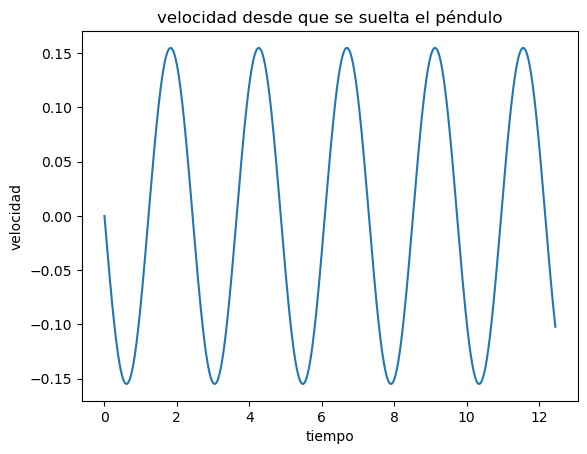

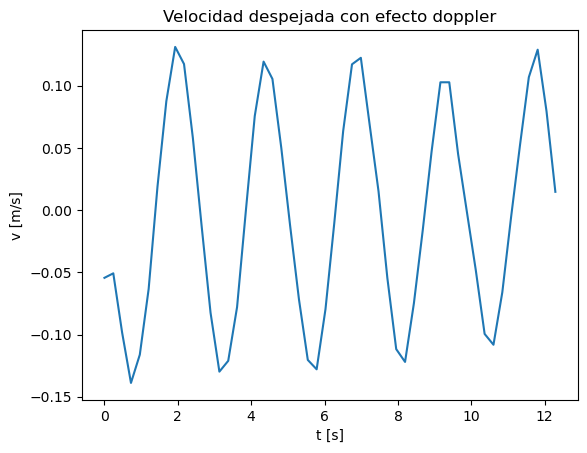

In [6]:
#grafica numérica de la velocidad usando runge kutta para solucionar pendulo simple
#catetos opuestos iniciales: 1=0.06, 2=0.11, 3=0.19, hice una prueba única con cateto opuesto = 0.4 todo en metros
import numpy as np
import matplotlib.pyplot as plt
L = 1.472
L_microfono = 1.392
g = 9.81
theta_0 = np.arcsin(0.06/L_microfono)
v_0 = 0
duracion_audio = t[-1]
h=0.01
Ntiempos = int(duracion_audio/h)
trk4 = np.arange(Ntiempos)*h
x=np.zeros([Ntiempos, 2])
x[0, 0] = theta_0
x[0,1] = v_0
def f(x, trk4, g=9.81, L=1.472):
    theta, velocidad = x
    return np.array([velocidad, -(g/L)*np.sin(theta)])
for i in range(Ntiempos-1):
     K1 = f(x[i], trk4[i])
     K2 = f(x[i]+K1*h/2, trk4[i]+h/2)
     K3 = f(x[i]+K2*h/2, trk4[i]+h/2)
     K4 = f(x[i]+K3*h , trk4[i]+h)
     x[i+1] = x[i] + (K1 + 2*K2 + 2*K3 + K4)*(h/6)
theta = x[:,0]
velocidad = x[:,1]

plt.plot(trk4, velocidad*L_microfono)
plt.title("velocidad desde que se suelta el péndulo")
plt.xlabel("tiempo")
plt.ylabel("velocidad")
plt.show()




#Ahora programo las formulas del efecto doppler
T = 273.15 +18.6
V_sonido = np.sqrt((1.4*8.314*T)/0.029)
f_emitida = 8000
velocidades_receptor = np.zeros(len(f_continua))
for i in range(0, len(t_f_continua_muestra)):
 v_r = V_sonido*((f_continua_muestra/f_emitida)-1) #porque es un arreglo de numpy (debería funcionar)
plt.plot(t_f_continua_muestra, v_r)
plt.xlabel("t [s]")
plt.ylabel("v [m/s]")
plt.title("Velocidad despejada con efecto doppler")
plt.show()



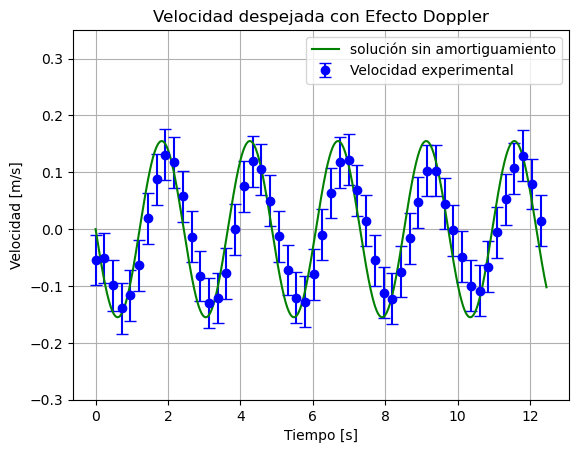

In [7]:
#análisis de error propagado en la velocidad
import numpy as np
error_termometro = 1
error_Hz_recibido = srr/resolucion
dv_vs = (f_continua_muestra/f_emitida)-1
dv_fr = V_sonido*(1/f_emitida)
dv_fe = V_sonido*(-(f_continua_muestra/f_emitida**2))
error_v_sonido = 0.5*np.abs((1/(np.sqrt(T)))*np.sqrt(1.4*8.314/0.029))*error_termometro
error_velocidad = np.sqrt((dv_vs*error_v_sonido)**2+(dv_fr*error_Hz_recibido)**2+(dv_fe*error_f_rep)**2) 

plt.errorbar(t_f_continua_muestra, v_r, yerr=error_velocidad, fmt='o', capsize=4, color='blue', label="Velocidad experimental")
plt.plot(trk4, velocidad*L_microfono, color="green", label = "solución sin amortiguamiento")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.title("Velocidad despejada con Efecto Doppler")
plt.grid(True)
plt.ylim((-0.3, 0.35))
plt.legend()
plt.savefig("Comparacion_Velocidad_PenduloA1.pdf")
plt.show()




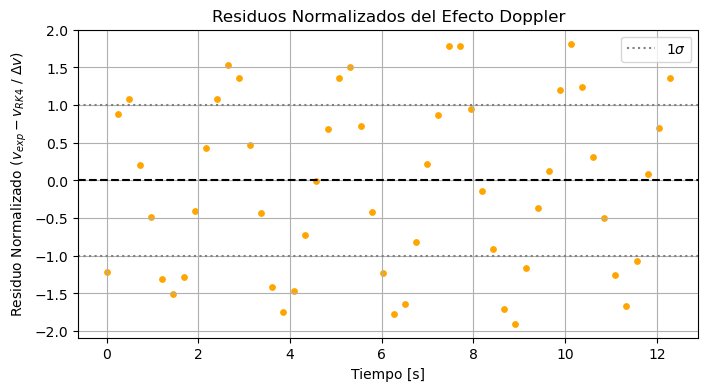

In [8]:
#análisis de error propagado en la velocidad
import numpy as np
error_termometro = 1
error_Hz_recibido = srr/resolucion
dv_vs = (f_continua_muestra/f_emitida)-1
dv_fr = V_sonido*(1/f_emitida)
dv_fe = V_sonido*(-(f_continua_muestra/f_emitida**2))
error_v_sonido = 0.5*np.abs((1/(np.sqrt(T)))*np.sqrt(1.4*8.314/0.029))*error_termometro
error_velocidad = np.sqrt((dv_vs*error_v_sonido)**2+(dv_fr*error_Hz_recibido)**2+(dv_fe*error_f_rep)**2) 

#créditos a la IA que lo hizo rápido
v_teorica_interpolada = np.interp(t_f_continua_muestra, trk4, velocidad * L_microfono)

# 2. Calcular los residuos (Datos Experimentales Doppler - Modelo Teórico RK4)
residuos_rk4 = v_r - v_teorica_interpolada

# 3. Graficar los residuos
#plt.figure(figsize=(8, 4))

# Línea base de error cero
#plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label="Error Cero")

# Puntos de los residuos
#plt.scatter(t_f_continua_muestra, residuos_rk4, color='green', s=15, label="Residuos (Exp - RK4)")

#plt.xlabel("Tiempo [s]")
#plt.ylabel("Residuo de Velocidad [m/s]")
#plt.title("Residuos: Datos Doppler vs Modelo Runge-Kutta")
#plt.legend()
#plt.grid(True)
#plt.show()

residuos_normalizados = residuos_rk4 / error_velocidad

# Graficar
plt.figure(figsize=(8, 4))
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='gray', linestyle=':', label=r'$1\sigma$')
plt.axhline(-1, color='gray', linestyle=':')

plt.scatter(t_f_continua_muestra, residuos_normalizados, color='orange', s=15)
plt.xlabel("Tiempo [s]")
plt.ylabel(r"Residuo Normalizado ($v_{exp} - v_{RK4}$ / $\Delta v$)")
plt.title("Residuos Normalizados del Efecto Doppler")
plt.legend()
plt.grid(True)
plt.savefig("ResiduosN_Pendulo_A1.pdf")
plt.show()

17000
stft shape=(8193, 208)


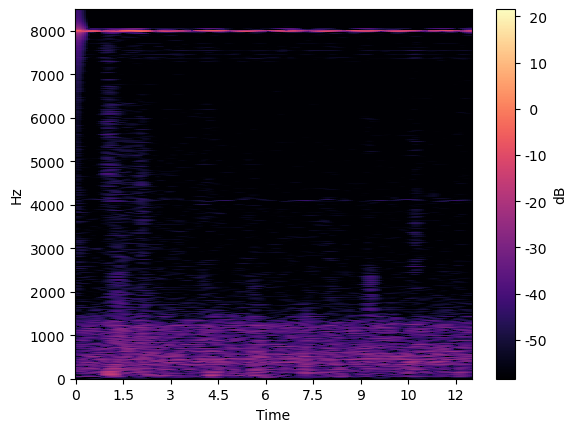

[7708 7709 7709 7709 7709 7709 7705 7705 7705 7705 7705 7705 7705 7705
 7705 7706 7706 7710 7710 7710 7710 7710 7710 7710 7710 7715 7715 7715
 7715 7715 7715 7715 7715 7715 7715 7715 7711 7711 7711 7711 7710 7710
 7709 7709 7709 7706 7705 7705 7705 7705 7705 7705 7705 7705 7705 7706
 7706 7707 7707 7707 7710 7712 7712 7712 7713 7714 7714 7715 7715 7715
 7715 7715 7715 7715 7715 7715 7714 7710 7710 7710 7710 7710 7710 7710
 7710 7710 7706 7706 7706 7706 7705 7705 7705 7706 7706 7706 7706 7706
 7708 7708 7708 7708 7712 7712 7712 7712 7714 7714 7715 7715 7715 7715
 7715 7715 7715 7715 7714 7710 7710 7710 7710 7710 7710 7710 7710 7710
 7706 7706 7706 7705 7705 7705 7705 7705 7706 7706 7706 7706 7708 7708
 7708 7708 7712 7712 7712 7713 7714 7714 7715 7715 7715 7715 7715 7715
 7715 7715 7715 7714 7710 7710 7710 7710 7710 7710 7710 7710 7706 7706
 7706 7706 7706 7705 7705 7706 7706 7706 7706 7709 7709 7708 7708 7708
 7710 7712 7712 7712 7712 7714 7714 7714 7715 7715 7715 7715 7715 7714
 7714 

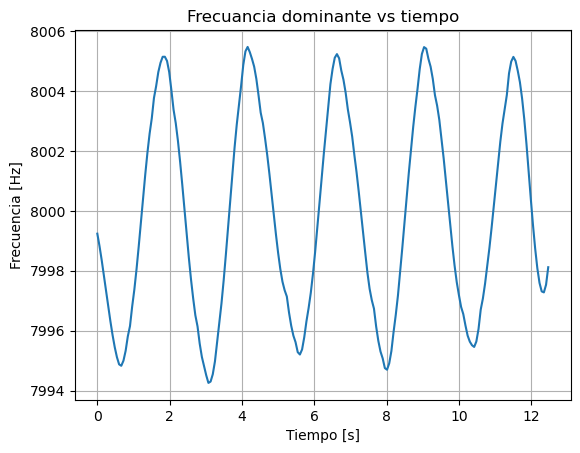

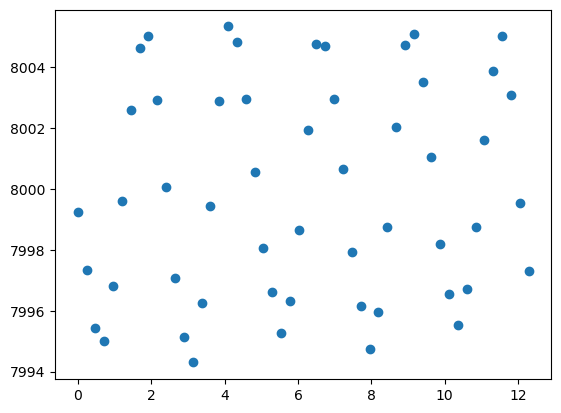

In [9]:
#PÉNDULO SIMPLE

#código sacado en su mayoría desde https://github.com/librosa/librosa/blob/main/docs/tutorials/02-display/02-spectrogram.py,
#borré la mayor parte de comentarios en inglés. las partes hechas por mí tienen nombres y comentarios poco serios, pero respetenlo.
# %%
# .. _tutorial-display-spectrogram:
#
# Spectrograms
# ------------
# The :ref:`earlier sections <tutorial-intro-frequency>` of this tutorial demonstrate basic
# usage of the short-time Fourier transform (STFT), which can be useful for visualizing how
# the frequency content of a signal changes over time.
# This kind of visualization is known as a **spectrogram**, and you may have encountered
# this idea before.
# While spectrograms can be interpreted as *images* and displayed using `matplotlib`'s
# general-purpose image display functions (e.g. `matplotlib.pyplot.imshow`), there are several
# subtleties that can arise and it takes a bit of effort to get it right.
#
# As an example, let's create an STFT and display it using `imshow` directly.
# We'll first set up our imports and load an example file.

# sphinx_gallery_thumbnail_number = 6
from scipy.signal import medfilt, savgol_filter
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import HTML
ruta_acceso = r"C:\Users\A\OneDrive\Escritorio\tópicos\audios\prueba_pendulo_a21.wav"
srr = 17000
hop_lengthh = 1024
y, sr = librosa.load(ruta_acceso, sr = srr, offset = 3.5, duration = 12.5) #sr = None para aumentar las muestras
print(sr)
#Si la frecuencia de muestreo es 44 100 muestras por cada segundo, puedo despejar el tiempo para el cual el código calculará las frecuencias
#y usarlo para determinar el armónico más fuerte del espectro, haciendo (indice * hop_length)/tasa_muestreo
# %%
# Now we can compute the STFT, create a figure, and call `imshow`.
# Note that when we call `imshow`, we have to convert the `stft` array from complex to real, or
# else it will fail due to a type mismatch.
resolucion = 16384
stft = librosa.stft(y, hop_length = hop_lengthh, n_fft = resolucion)
print(f"stft shape={stft.shape}")
#fig, ax = plt.subplots()
#ax.imshow(np.abs(stft))
#esta parte la hice yo, quizas se puede hacer más rápido con numpy pero usé lo que sabía perdoneme profe
t= np.zeros(stft.shape[1])
for i in range(0, stft.shape[1]):
    t[i] = (i*hop_lengthh)/srr    

#fig, ax = plt.subplots()
#librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB")
fig, ax = plt.subplots()
img = librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB", sr=srr, hop_length = hop_lengthh)
librosa.display.colorbar_db(img)
plt.savefig("Espectrograma_Pendulo_A2.pdf")
plt.show()
frecuencias = librosa.fft_frequencies(sr=srr, n_fft=resolucion)
frecuencias_absolutas = np.abs(stft) #por si acaso? me dijeron que lo haga
#ahora voy a filtrar un rango de frecuencia
frecuencias_filtradas = []
indices_frecuencias_filtradas = []
amplitudes_filtradas = []

for i in range(0, len(frecuencias)):
    if frecuencias[i]>=7800 and frecuencias[i]<=8200:
        frecuencias_filtradas.append(frecuencias[i])
        amplitudes_filtradas.append(frecuencias_absolutas[i, :])
        
#paso las listas a arreglos numpy para trabajarlos más fácil y que me compile el codigo
frecuencias_filtradas = np.array(frecuencias_filtradas)
amplitudes_filtradas = np.array(amplitudes_filtradas)
indices_frecuencias_filtradas = np.argmax(amplitudes_filtradas, axis=0)
f_dominante = frecuencias_filtradas[indices_frecuencias_filtradas]

f_dominante_promedio = medfilt(f_dominante, kernel_size=7) #esto lo hice con IA, se supone que filtra el ruido
indices_f_max = np.argmax(frecuencias_absolutas, axis=0) 
print(indices_f_max) #no muestra todos los indices pero elijo confiar? el np.argmax sin el axis=0 me devuelve un único valor (imagino que de todo el audio)
#esta parte si funciona pero hay código que no usamos realmente, son vestigios de codigos anteriores
no_se_si_funciona = frecuencias[indices_f_max]
print(no_se_si_funciona)

#un ajuste lineal para que los gráficos no se vean no continuos
f_continua = savgol_filter(f_dominante_promedio, window_length=21, polyorder=3) #esto lo hice con IA


largo_f_continua = len(f_continua)
print(largo_f_continua)

#extraigo una muestra para no graficar como 200 puntos de velocidad, la muestra ES representativa porque pasó por promedios y ajustes
f_continua_muestra = f_continua[0:largo_f_continua:4]
t_f_continua_muestra = t[0:largo_f_continua:4]


plt.plot(t, f_continua)
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.title("Frecuancia dominante vs tiempo")
plt.grid(True)
plt.savefig("Frecuencia_Dominante_PenduloA2.pdf")
plt.show()

plt.scatter(t_f_continua_muestra, f_continua_muestra)
plt.show()



#plt.plot(t_f_dom, f_dominante)
#plt.show()
#Ahora nos falta separar los gráficos y hacer una máscara AYUDAAAAAAA




#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB")
#librosa.display.colorbar_db(img)


#fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[4, 1])
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB", ax=ax[0])
#librosa.display.colorbar_db(img)


#ax[0].legend(loc="upper right")
#ax[0].label_outer("ola")
#librosa.display.waveshow(y=y, sr=sr, ax=ax[1])



# Use the native sampling rate of the example by setting sr=None
#y, sr = librosa.loadx(ruta_acceso, sr=None)

# Use larger frames (4096 samples) to account for the higher sampling rate
# Use a smaller hop length to get a higher time resolution in the stft
#stft = librosa.stft(y, n_fft=8192, hop_length=256)
#print(f"stft shape={stft.shape}")

# %%
# Now we can supply our analysis parameters to `specshow` so that axes are constructed
# properly.
# While we're at it, we can also change the threshold for decibel scaling by setting `top_db`
# (which defaults to 80, but let's set it to 60 to suppress low-amplitude noise).
# Finally, we can choose a different colormap for sequential data by setting `cmap_seq=`.
# Here we'll use a black-on-white colormap, suitable for print media.

#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB",
                              # sr=sr, hop_length=256, top_db=60,
                               #cmap_seq="gray_r")
#librosa.display.colorbar_db(img)

# %%
# Summary and tips
# ----------------
# We've really only scratched the surface when it comes to the functionality provided by
# `specshow`, and the subsequent sections in this tutorial will dig into the details.
#
# A few things that can be helpful to keep in mind:
#   - The most important parameters are `x_axis` and `y_axis`.  Most of the remaining
#     parameters are there to support unit conversion for different axis scalings.
#   - There is nothing special about the orientation here: any axis can be a time axis or a
#     frequency axis.  This makes it easy to draw sideways spectrograms, time-by-time plots,
#     frequency-by-frequency plots, etc.  The section on :ref:`non-spectral <tutorial-display-nonspectral>`
#     data visualization provides some examples of this.
#   - The underlying display object is generated by `matplotlib.pyplot.pcolormesh`.  Any
#     parameters acceptable to `pcolormesh` can be passed into `specshow` as well.





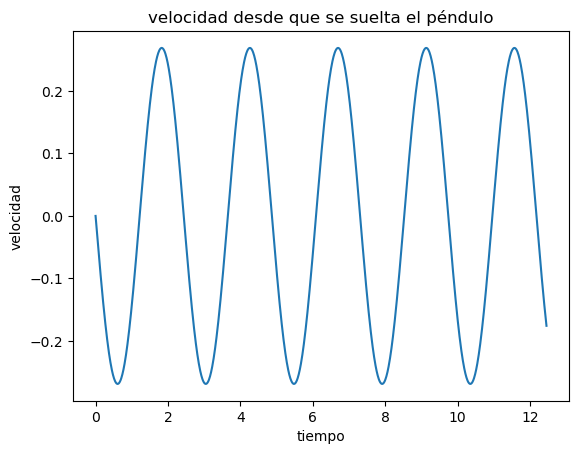

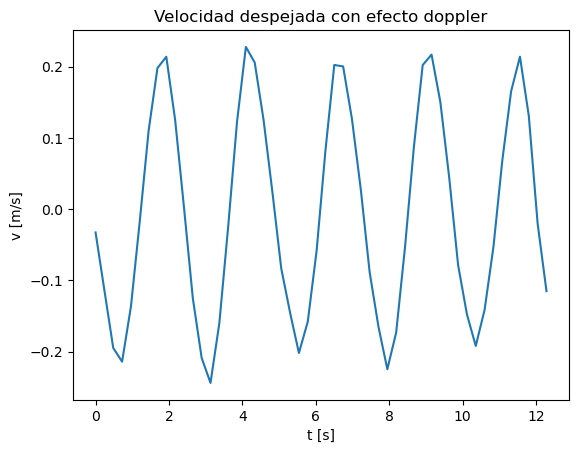

In [10]:
#grafica numérica de la velocidad usando runge kutta para solucionar pendulo simple
#catetos opuestos iniciales: 1=0.06, 2=0.11, 3=0.19, hice una prueba única con cateto opuesto = 0.4 todo en metros
import numpy as np
import matplotlib.pyplot as plt
L = 1.472
L_microfono = 1.392
g = 9.81
theta_0 = np.arcsin(0.11/L)
v_0 = 0
duracion_audio = t[-1]
h=0.01
Ntiempos = int(duracion_audio/h)
trk4 = np.arange(Ntiempos)*h
x=np.zeros([Ntiempos, 2])
x[0, 0] = theta_0
x[0,1] = v_0
def f(x, trk4, g=9.81, L=1.472):
    theta, velocidad = x
    return np.array([velocidad, -(g/L)*np.sin(theta)])
for i in range(Ntiempos-1):
     K1 = f(x[i], trk4[i])
     K2 = f(x[i]+K1*h/2, trk4[i]+h/2)
     K3 = f(x[i]+K2*h/2, trk4[i]+h/2)
     K4 = f(x[i]+K3*h , trk4[i]+h)
     x[i+1] = x[i] + (K1 + 2*K2 + 2*K3 + K4)*(h/6)
theta = x[:,0]
velocidad = x[:,1]

plt.plot(trk4, velocidad*L_microfono)
plt.title("velocidad desde que se suelta el péndulo")
plt.xlabel("tiempo")
plt.ylabel("velocidad")
plt.show()




#Ahora programo las formulas del efecto doppler
T = 273.15 +18.6
V_sonido = np.sqrt((1.4*8.314*T)/0.029)
f_emitida = 8000
velocidades_receptor = np.zeros(len(f_continua))
for i in range(0, len(t_f_continua_muestra)):
 v_r = V_sonido*((f_continua_muestra/f_emitida)-1) #porque es un arreglo de numpy (debería funcionar)
plt.plot(t_f_continua_muestra, v_r)
plt.xlabel("t [s]")
plt.ylabel("v [m/s]")
plt.title("Velocidad despejada con efecto doppler")
plt.show()



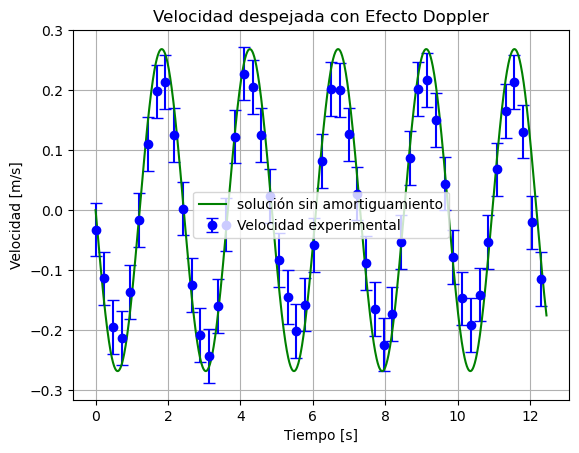

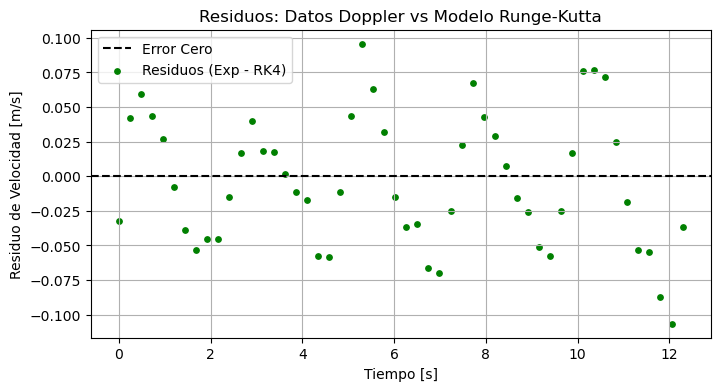

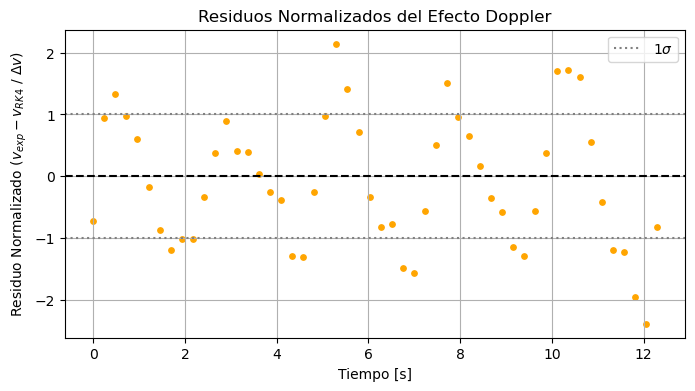

In [11]:
#análisis de error propagado en la velocidad
import numpy as np
error_termometro = 1
error_Hz_recibido = srr/resolucion
dv_vs = (f_continua_muestra/f_emitida)-1
dv_fr = V_sonido*(1/f_emitida)
dv_fe = V_sonido*(-(f_continua_muestra/f_emitida**2))
error_v_sonido = 0.5*np.abs((1/(np.sqrt(T)))*np.sqrt(1.4*8.314/0.029))*error_termometro
error_velocidad = np.sqrt((dv_vs*error_v_sonido)**2+(dv_fr*error_Hz_recibido)**2+(dv_fe*error_f_rep)**2) 

plt.errorbar(t_f_continua_muestra, v_r, yerr=error_velocidad, fmt='o', capsize=4, color='blue', label="Velocidad experimental")
plt.plot(trk4, velocidad*L_microfono, color="green", label="solución sin amortiguamiento")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.title("Velocidad despejada con Efecto Doppler")
plt.grid(True)
plt.legend()
plt.savefig("Comparacion_velocidad_penduloA2.pdf")
plt.show()

#créditos a la IA que lo hizo rápido
v_teorica_interpolada = np.interp(t_f_continua_muestra, trk4, velocidad * L_microfono)

# 2. Calcular los residuos (Datos Experimentales Doppler - Modelo Teórico RK4)
residuos_rk4 = v_r - v_teorica_interpolada

# 3. Graficar los residuos
plt.figure(figsize=(8, 4))

# Línea base de error cero
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label="Error Cero")

# Puntos de los residuos
plt.scatter(t_f_continua_muestra, residuos_rk4, color='green', s=15, label="Residuos (Exp - RK4)")

plt.xlabel("Tiempo [s]")
plt.ylabel("Residuo de Velocidad [m/s]")
plt.title("Residuos: Datos Doppler vs Modelo Runge-Kutta")
plt.legend()
plt.grid(True)
plt.show()

residuos_normalizados = residuos_rk4 / error_velocidad

# Graficar
plt.figure(figsize=(8, 4))
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='gray', linestyle=':', label=r'$1\sigma$')
plt.axhline(-1, color='gray', linestyle=':')

plt.scatter(t_f_continua_muestra, residuos_normalizados, color='orange', s=15)
plt.xlabel("Tiempo [s]")
plt.ylabel(r"Residuo Normalizado ($v_{exp} - v_{RK4}$ / $\Delta v$)")
plt.title("Residuos Normalizados del Efecto Doppler")
plt.legend()
plt.grid(True)
plt.savefig("ResiduosN_PenduloA2.pdf")
plt.show()

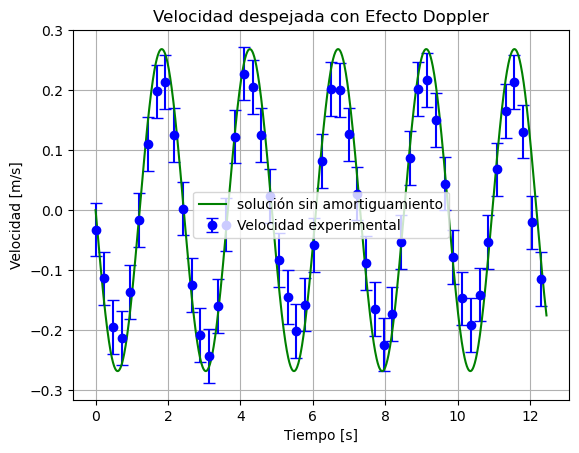

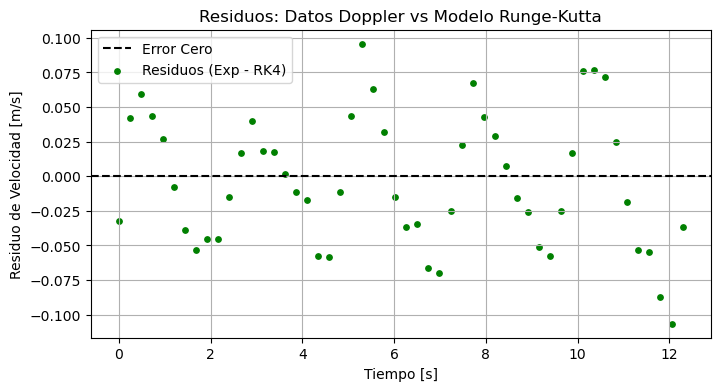

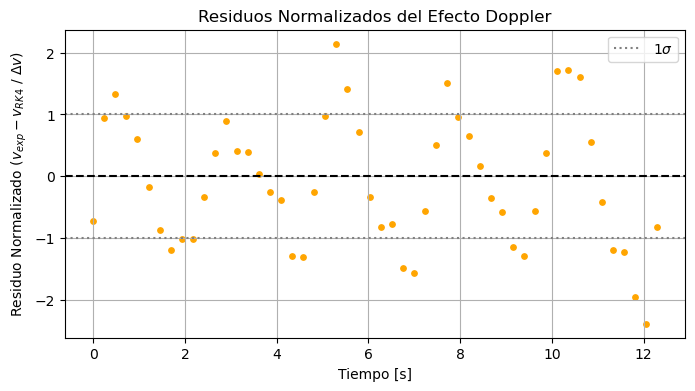

In [12]:
#análisis de error propagado en la velocidad
import numpy as np
error_termometro = 1
error_Hz_recibido = srr/resolucion
dv_vs = (f_continua_muestra/f_emitida)-1
dv_fr = V_sonido*(1/f_emitida)
dv_fe = V_sonido*(-(f_continua_muestra/f_emitida**2))
error_v_sonido = 0.5*np.abs((1/(np.sqrt(T)))*np.sqrt(1.4*8.314/0.029))*error_termometro
error_velocidad = np.sqrt((dv_vs*error_v_sonido)**2+(dv_fr*error_Hz_recibido)**2+(dv_fe*error_f_rep)**2) 

plt.errorbar(t_f_continua_muestra, v_r, yerr=error_velocidad, fmt='o', capsize=4, color='blue', label="Velocidad experimental")
plt.plot(trk4, velocidad*L_microfono, color="green", label="solución sin amortiguamiento")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.title("Velocidad despejada con Efecto Doppler")
plt.grid(True)
plt.legend()
plt.show()

#créditos a la IA que lo hizo rápido
v_teorica_interpolada = np.interp(t_f_continua_muestra, trk4, velocidad * L_microfono)

# 2. Calcular los residuos (Datos Experimentales Doppler - Modelo Teórico RK4)
residuos_rk4 = v_r - v_teorica_interpolada

# 3. Graficar los residuos
plt.figure(figsize=(8, 4))

# Línea base de error cero
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label="Error Cero")

# Puntos de los residuos
plt.scatter(t_f_continua_muestra, residuos_rk4, color='green', s=15, label="Residuos (Exp - RK4)")

plt.xlabel("Tiempo [s]")
plt.ylabel("Residuo de Velocidad [m/s]")
plt.title("Residuos: Datos Doppler vs Modelo Runge-Kutta")
plt.legend()
plt.grid(True)
plt.show()

residuos_normalizados = residuos_rk4 / error_velocidad

# Graficar
plt.figure(figsize=(8, 4))
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='gray', linestyle=':', label=r'$1\sigma$')
plt.axhline(-1, color='gray', linestyle=':')

plt.scatter(t_f_continua_muestra, residuos_normalizados, color='orange', s=15)
plt.xlabel("Tiempo [s]")
plt.ylabel(r"Residuo Normalizado ($v_{exp} - v_{RK4}$ / $\Delta v$)")
plt.title("Residuos Normalizados del Efecto Doppler")
plt.legend()
plt.grid(True)
plt.show()